# CC3104 - Laboratorio 5: entrega parcial

**Integrantes:** Andy Fuentes - 22944; Diederich Solís - 22952; Diego Linares - 221256  
**Curso:** CC3104 - Aprendizaje por Refuerzo  
**Fecha:** 20 de agosto de 2026

**Dependencias:** Python 3.10 o posterior, `gymnasium>=1.0`, `numpy` y `matplotlib`.

Este notebook implementa el Task 2. Como el problema tiene dos acciones y requiere comparar recompensa de control, usamos la extensión de TD semi-gradiente a valores de acción: SARSA semi-gradiente. Se mantiene un único vector de pesos y una representación por bloques:

\[
\Phi(s,0)=[x(s),0],\quad \Phi(s,1)=[0,x(s)],\quad
\hat Q(s,a;w)=w^\top\Phi(s,a),
\]

\[
\delta_t=R_{t+1}+\gamma\hat Q(S_{t+1},A_{t+1};w)-\hat Q(S_t,A_t;w),
\]

\[
w\leftarrow w+\alpha\,\delta_t\,\Phi(S_t,A_t).
\]

Esta actualización conserva exactamente la estructura semi-gradiente indicada en las diapositivas; la única extensión es incluir la acción en las características. Para la línea base se usa Q-Learning tabular con 5 niveles por variable, es decir, \(5^3\times2=250\) entradas.

## Decisiones de diseño y reproducibilidad

- Estado continuo: densidad, velocidad y espera, todas en `[0,1]`.
- Acciones: `0 = mantener fase`, `1 = cambiar a la siguiente fase`.
- Recompensa: penaliza espera y densidad; agrega un término positivo cuando el flujo supera 0.14 y un costo pequeño por cambio.
- Características: `[1,d,v,e,de,dv,ve,d²,v²,e²]`.
- Hiperparámetros: `gamma=0.92`, `alpha_lineal=0.012`, `alpha_tabular=0.14`, epsilon decreciente hasta 0.05.
- El ECM se evalúa después de cada episodio sobre los mismos 100 estados generados con semilla 3104.

El entorno se valida con `gymnasium.utils.env_checker.check_env`, y el notebook se entrega ejecutado de principio a fin.

In [1]:
# Definiciones del entorno, características, agentes y experimento
"""Experimento reproducible para el Laboratorio 5 de CC3104.

Compara control SARSA semi-gradiente con aproximacion lineal y Q-Learning
tabular en el mismo entorno continuo de una interseccion simplificada.
"""

from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import gymnasium as gym
from gymnasium import spaces
from gymnasium.utils.env_checker import check_env


class TrafficIntersectionEnv(gym.Env):
    """Interseccion simplificada con estado continuo [densidad, velocidad, espera]."""

    metadata = {"render_modes": []}

    def __init__(self, horizon: int = 100):
        super().__init__()
        self.observation_space = spaces.Box(0.0, 1.0, shape=(3,), dtype=np.float32)
        self.action_space = spaces.Discrete(2)
        self.horizon = horizon
        self.state = np.zeros(3, dtype=np.float32)
        self.t = 0

    def reset(self, *, seed: int | None = None, options=None):
        super().reset(seed=seed)
        self.t = 0
        density = self.np_random.uniform(0.25, 0.75)
        speed = np.clip(1.0 - density + self.np_random.normal(0, 0.05), 0, 1)
        wait = self.np_random.uniform(0.05, 0.35)
        self.state = np.array([density, speed, wait], dtype=np.float32)
        return self.state.copy(), {}

    def step(self, action: int):
        if not self.action_space.contains(action):
            raise ValueError(f"Accion invalida: {action}")
        density, speed, wait = map(float, self.state)
        action = int(action)

        # Demanda variable: patron suave mas ruido. Cambiar fase libera una cola
        # congestionada, pero introduce una pequena perdida por transicion.
        arrival = 0.055 + 0.025 * np.sin(2 * np.pi * self.t / 40)
        arrival += self.np_random.normal(0, 0.012)
        if action == 0:  # mantener fase actual
            service = 0.035 + 0.10 * speed
            switch_cost = 0.0
        else:  # cambiar a la fase siguiente
            service = 0.055 + 0.19 * density + 0.08 * wait
            switch_cost = 0.045

        flow = float(np.clip(min(density + max(arrival, 0), service), 0, 1))
        next_density = np.clip(density + arrival - flow, 0, 1)
        desired_speed = np.clip(1.0 - 0.90 * next_density - 0.10 * action, 0, 1)
        next_speed = np.clip(0.70 * speed + 0.30 * desired_speed + self.np_random.normal(0, 0.02), 0, 1)
        next_wait = np.clip(wait + 0.12 * next_density - 0.10 * flow, 0, 1)

        # Recompensa negativa por espera y positiva si el flujo supera el umbral.
        reward = -next_wait - 0.20 * next_density - switch_cost
        reward += 0.45 if flow > 0.14 else 0.0

        self.t += 1
        terminated = False
        truncated = self.t >= self.horizon
        self.state = np.array([next_density, next_speed, next_wait], dtype=np.float32)
        return self.state.copy(), float(reward), terminated, truncated, {"flow": flow}


def features(state: np.ndarray) -> np.ndarray:
    """x(s) = [1, d, v, e, de, dv, ve, d^2, v^2, e^2]."""
    d, v, e = np.asarray(state, dtype=float)
    return np.array([1.0, d, v, e, d * e, d * v, v * e, d * d, v * v, e * e])


def action_features(state: np.ndarray, action: int) -> np.ndarray:
    """Phi(s,a): dos bloques de x(s), uno por cada accion (20 parametros)."""
    phi = np.zeros(20, dtype=float)
    start = int(action) * 10
    phi[start : start + 10] = features(state)
    return phi


def linear_q_values(weights: np.ndarray, state: np.ndarray) -> np.ndarray:
    """Q aproximado para ambas acciones con un unico vector w en R^20."""
    return np.array([weights @ action_features(state, action) for action in range(2)])


def discretize(state: np.ndarray, levels: int = 5) -> tuple[int, int, int]:
    indices = np.floor(np.asarray(state) * levels).astype(int)
    return tuple(np.clip(indices, 0, levels - 1))


def epsilon_greedy(values: np.ndarray, epsilon: float, rng: np.random.Generator) -> int:
    if rng.random() < epsilon:
        return int(rng.integers(len(values)))
    maxima = np.flatnonzero(values == values.max())
    return int(rng.choice(maxima))


def make_fixed_states(seed: int = 3104, n: int = 100) -> np.ndarray:
    rng = np.random.default_rng(seed)
    return rng.uniform(0, 1, size=(n, 3))


def value_mse(weights: np.ndarray, q_table: np.ndarray, sample: np.ndarray) -> float:
    linear_values = np.array([linear_q_values(weights, s).max() for s in sample])
    tabular_values = np.array([q_table[discretize(s)].max() for s in sample])
    return float(np.mean((linear_values - tabular_values) ** 2))


def train_one_seed(seed: int, episodes: int = 600, horizon: int = 100):
    env_linear = TrafficIntersectionEnv(horizon=horizon)
    env_tabular = TrafficIntersectionEnv(horizon=horizon)
    rng_linear = np.random.default_rng(seed + 11)
    rng_tabular = np.random.default_rng(seed + 29)

    weights = np.zeros(20, dtype=float)
    q_table = np.zeros((5, 5, 5, 2), dtype=float)
    sample = make_fixed_states()

    reward_linear = np.zeros(episodes)
    reward_tabular = np.zeros(episodes)
    weight_norm = np.zeros(episodes)
    mse = np.zeros(episodes)

    alpha_linear, alpha_tabular, gamma = 0.012, 0.14, 0.92

    for episode in range(episodes):
        epsilon = max(0.05, 0.35 * (0.994 ** episode))

        # SARSA semi-gradiente: target con bootstrap tratado como constante.
        state, _ = env_linear.reset(seed=seed * 10000 + episode)
        action = epsilon_greedy(linear_q_values(weights, state), epsilon, rng_linear)
        for _ in range(horizon):
            next_state, reward, terminated, truncated, _ = env_linear.step(action)
            next_action = epsilon_greedy(linear_q_values(weights, next_state), epsilon, rng_linear)
            phi = action_features(state, action)
            q_now = weights @ phi
            bootstrap = 0.0 if (terminated or truncated) else weights @ action_features(next_state, next_action)
            delta = reward + gamma * bootstrap - q_now
            # Semi-gradiente de Q_hat(s,a;w)=w^T Phi(s,a): gradiente = Phi(s,a).
            weights += alpha_linear * delta * phi
            reward_linear[episode] += reward
            state, action = next_state, next_action
            if terminated or truncated:
                break

        # Q-Learning tabular: misma dinamica y mismo calendario de exploracion.
        state, _ = env_tabular.reset(seed=seed * 10000 + episode)
        for _ in range(horizon):
            idx = discretize(state)
            action = epsilon_greedy(q_table[idx], epsilon, rng_tabular)
            next_state, reward, terminated, truncated, _ = env_tabular.step(action)
            next_idx = discretize(next_state)
            bootstrap = 0.0 if (terminated or truncated) else q_table[next_idx].max()
            td_error = reward + gamma * bootstrap - q_table[idx + (action,)]
            q_table[idx + (action,)] += alpha_tabular * td_error
            reward_tabular[episode] += reward
            state = next_state
            if terminated or truncated:
                break

        weight_norm[episode] = np.linalg.norm(weights)
        mse[episode] = value_mse(weights, q_table, sample)

    return {
        "linear_reward": reward_linear,
        "tabular_reward": reward_tabular,
        "weight_norm": weight_norm,
        "mse": mse,
        "weights": weights,
        "q_table": q_table,
    }


def moving_average(values: np.ndarray, window: int = 30) -> np.ndarray:
    if values.ndim == 2:
        values = values.mean(axis=0)
    kernel = np.ones(window) / window
    valid = np.convolve(values, kernel, mode="valid")
    return np.r_[np.full(window - 1, np.nan), valid]


def first_sustained_advantage(linear: np.ndarray, tabular: np.ndarray, run: int = 20):
    advantage = moving_average(linear) - moving_average(tabular)
    good = np.nan_to_num(advantage > 0, nan=False)
    for start in range(len(good) - run + 1):
        if good[start : start + run].all():
            return start + 1
    return None


def create_evidence_figure(output_dir: Path, summary: dict) -> None:
    """Crea una evidencia visual legible a partir de la corrida validada."""
    rows = [
        ("Interfaz del entorno", "Gymnasium check_env: aprobado"),
        ("Versión de Gymnasium", gym.__version__),
        ("Semillas independientes", ", ".join(map(str, summary["seeds"]))),
        ("Entrenamiento", f'{summary["episodes"]} episodios x 100 pasos'),
        ("Parámetros lineales de control", str(summary["linear_q_parameters"])),
        ("Entradas de Q tabular", str(summary["tabular_q_entries_5_levels"])),
        ("Ventaja lineal sostenida", f'Episodio {summary["first_sustained_linear_advantage_episode"]}'),
        ("Recompensa final lineal", f'{summary["linear_reward_last50_mean"]:.2f} (últimos 50)'),
        ("Recompensa final tabular", f'{summary["tabular_reward_last50_mean"]:.2f} (últimos 50)'),
        ("Norma final media de w", f'{summary["weight_norm_final_mean"]:.2f}'),
        ("ECM final medio", f'{summary["mse_final_mean"]:.2f}'),
    ]
    fig, ax = plt.subplots(figsize=(9, 5.4))
    ax.axis("off")
    ax.set_title("Evidencia de ejecución y configuración experimental", fontsize=15, pad=14)
    table = ax.table(
        cellText=rows,
        colLabels=["Comprobación", "Resultado registrado"],
        colLoc="left",
        cellLoc="left",
        colWidths=[0.47, 0.53],
        loc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(10.5)
    table.scale(1, 1.55)
    for (row, _), cell in table.get_celld().items():
        cell.set_edgecolor("#555555")
        cell.set_linewidth(0.6)
        if row == 0:
            cell.set_facecolor("#e6e6e6")
            cell.set_text_props(weight="bold")
        elif row % 2 == 0:
            cell.set_facecolor("#f7f7f7")
    fig.tight_layout()
    fig.savefig(output_dir / "fig4_evidencia_ejecucion.png", dpi=180, bbox_inches="tight")
    plt.close(fig)


def run_experiment(output_dir: str | Path, seeds=(7, 19, 31, 43, 59), episodes: int = 600):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    runs = [train_one_seed(seed, episodes=episodes) for seed in seeds]
    stacked = {key: np.stack([run[key] for run in runs]) for key in ["linear_reward", "tabular_reward", "weight_norm", "mse"]}

    x_axis = np.arange(1, episodes + 1)
    lin_mean = moving_average(stacked["linear_reward"])
    tab_mean = moving_average(stacked["tabular_reward"])

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(x_axis, lin_mean, label="SARSA semi-gradiente lineal", color="#155e75")
    ax.plot(x_axis, tab_mean, label="Q-Learning tabular", color="#c2410c")
    ax.set(xlabel="Episodio", ylabel="Recompensa acumulada (media movil 30)", title="Curvas de aprendizaje")
    ax.grid(alpha=0.25); ax.legend(); fig.tight_layout()
    fig.savefig(output_dir / "fig1_curvas_aprendizaje.png", dpi=180); plt.close(fig)

    fig, ax = plt.subplots(figsize=(9, 5))
    norm_mean = stacked["weight_norm"].mean(axis=0)
    norm_std = stacked["weight_norm"].std(axis=0)
    ax.plot(x_axis, norm_mean, color="#155e75")
    ax.fill_between(x_axis, norm_mean - norm_std, norm_mean + norm_std, color="#155e75", alpha=0.18, label="+- 1 desviacion")
    ax.set(xlabel="Episodio", ylabel="Norma L2 de w", title="Evolucion de la norma de los pesos")
    ax.grid(alpha=0.25); ax.legend(); fig.tight_layout()
    fig.savefig(output_dir / "fig2_norma_pesos.png", dpi=180); plt.close(fig)

    fig, ax = plt.subplots(figsize=(9, 5))
    mse_mean = stacked["mse"].mean(axis=0)
    mse_std = stacked["mse"].std(axis=0)
    ax.plot(x_axis, mse_mean, color="#6d28d9")
    ax.fill_between(x_axis, np.maximum(0, mse_mean - mse_std), mse_mean + mse_std, color="#6d28d9", alpha=0.16, label="+- 1 desviacion")
    ax.set(xlabel="Episodio", ylabel="ECM entre V lineal y V tabular", title="Error sobre 100 estados fijos")
    ax.grid(alpha=0.25); ax.legend(); fig.tight_layout()
    fig.savefig(output_dir / "fig3_error_cuadratico.png", dpi=180); plt.close(fig)

    tail = 50
    summary = {
        "seeds": list(seeds),
        "episodes": episodes,
        "first_sustained_linear_advantage_episode": first_sustained_advantage(stacked["linear_reward"], stacked["tabular_reward"]),
        "linear_reward_last50_mean": float(stacked["linear_reward"][:, -tail:].mean()),
        "linear_reward_last50_std_across_all": float(stacked["linear_reward"][:, -tail:].std()),
        "tabular_reward_last50_mean": float(stacked["tabular_reward"][:, -tail:].mean()),
        "tabular_reward_last50_std_across_all": float(stacked["tabular_reward"][:, -tail:].std()),
        "weight_norm_final_mean": float(stacked["weight_norm"][:, -1].mean()),
        "weight_norm_last50_slope_mean": float(np.mean([np.polyfit(np.arange(tail), row[-tail:], 1)[0] for row in stacked["weight_norm"]])),
        "mse_final_mean": float(stacked["mse"][:, -1].mean()),
        "linear_v_parameters": 10,
        "linear_q_parameters": 20,
        "tabular_q_entries_5_levels": 250,
        "tabular_q_entries_10_levels": 2000,
    }
    (output_dir / "resultados_resumen.json").write_text(json.dumps(summary, indent=2), encoding="utf-8")
    create_evidence_figure(output_dir, summary)
    return summary, stacked


def validate_environment() -> bool:
    """Valida formalmente la interfaz Gymnasium y los espacios declarados."""
    check_env(TrafficIntersectionEnv(), skip_render_check=True)
    return True



In [2]:
# Verifica que reset(), step() y los espacios cumplen la API oficial de Gymnasium.
validate_environment()

# Cinco semillas reducen la dependencia de una sola trayectoria aleatoria.
summary, stacked = run_experiment("resultados", seeds=(7, 19, 31, 43, 59), episodes=600)
summary

{'seeds': [7, 19, 31, 43, 59],
 'episodes': 600,
 'first_sustained_linear_advantage_episode': 30,
 'linear_reward_last50_mean': -10.038011091762709,
 'linear_reward_last50_std_across_all': 4.487007755951002,
 'tabular_reward_last50_mean': -9.596149963870827,
 'tabular_reward_last50_std_across_all': 5.754309545052008,
 'weight_norm_final_mean': 7.008721535930728,
 'weight_norm_last50_slope_mean': 0.004751300108236231,
 'mse_final_mean': 14.117740404378747,
 'linear_v_parameters': 10,
 'linear_q_parameters': 20,
 'tabular_q_entries_5_levels': 250,
 'tabular_q_entries_10_levels': 2000}

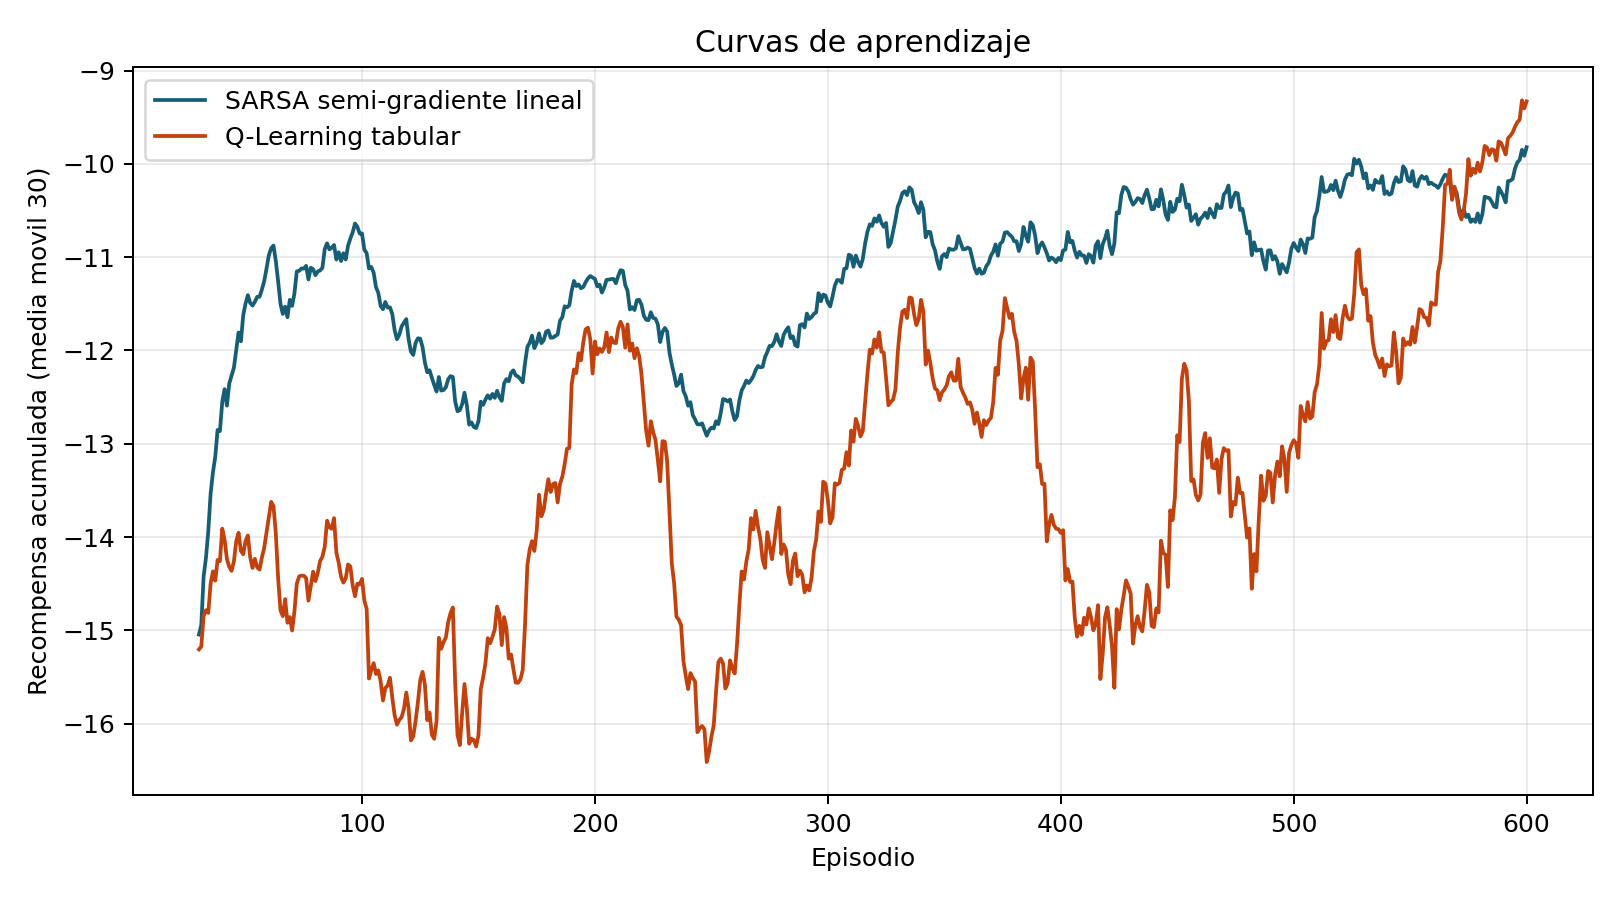

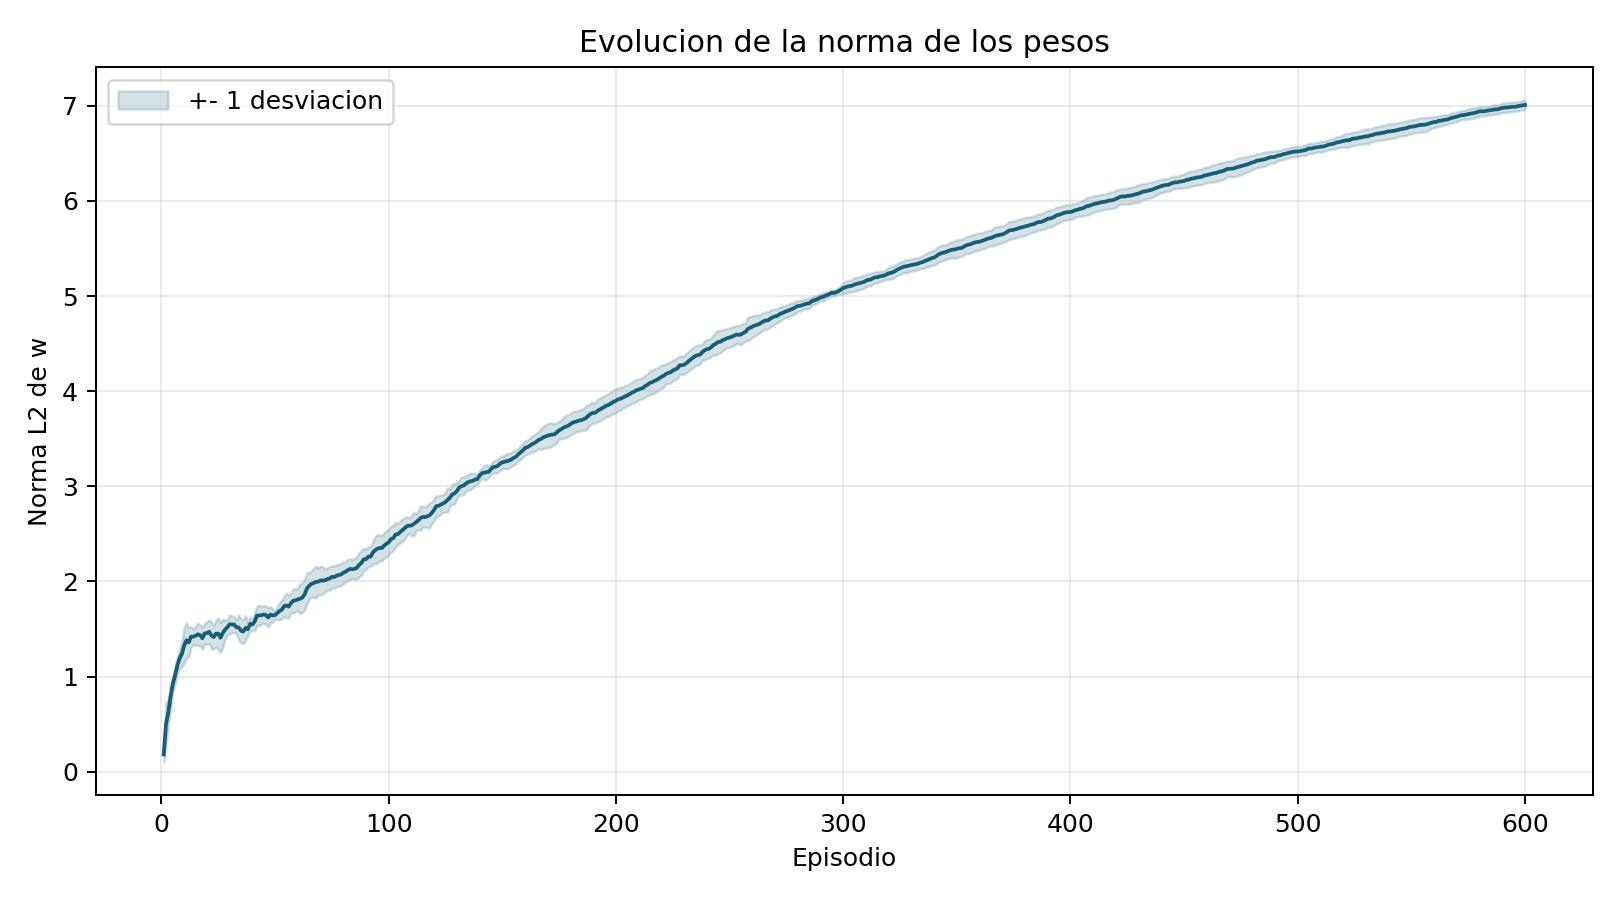

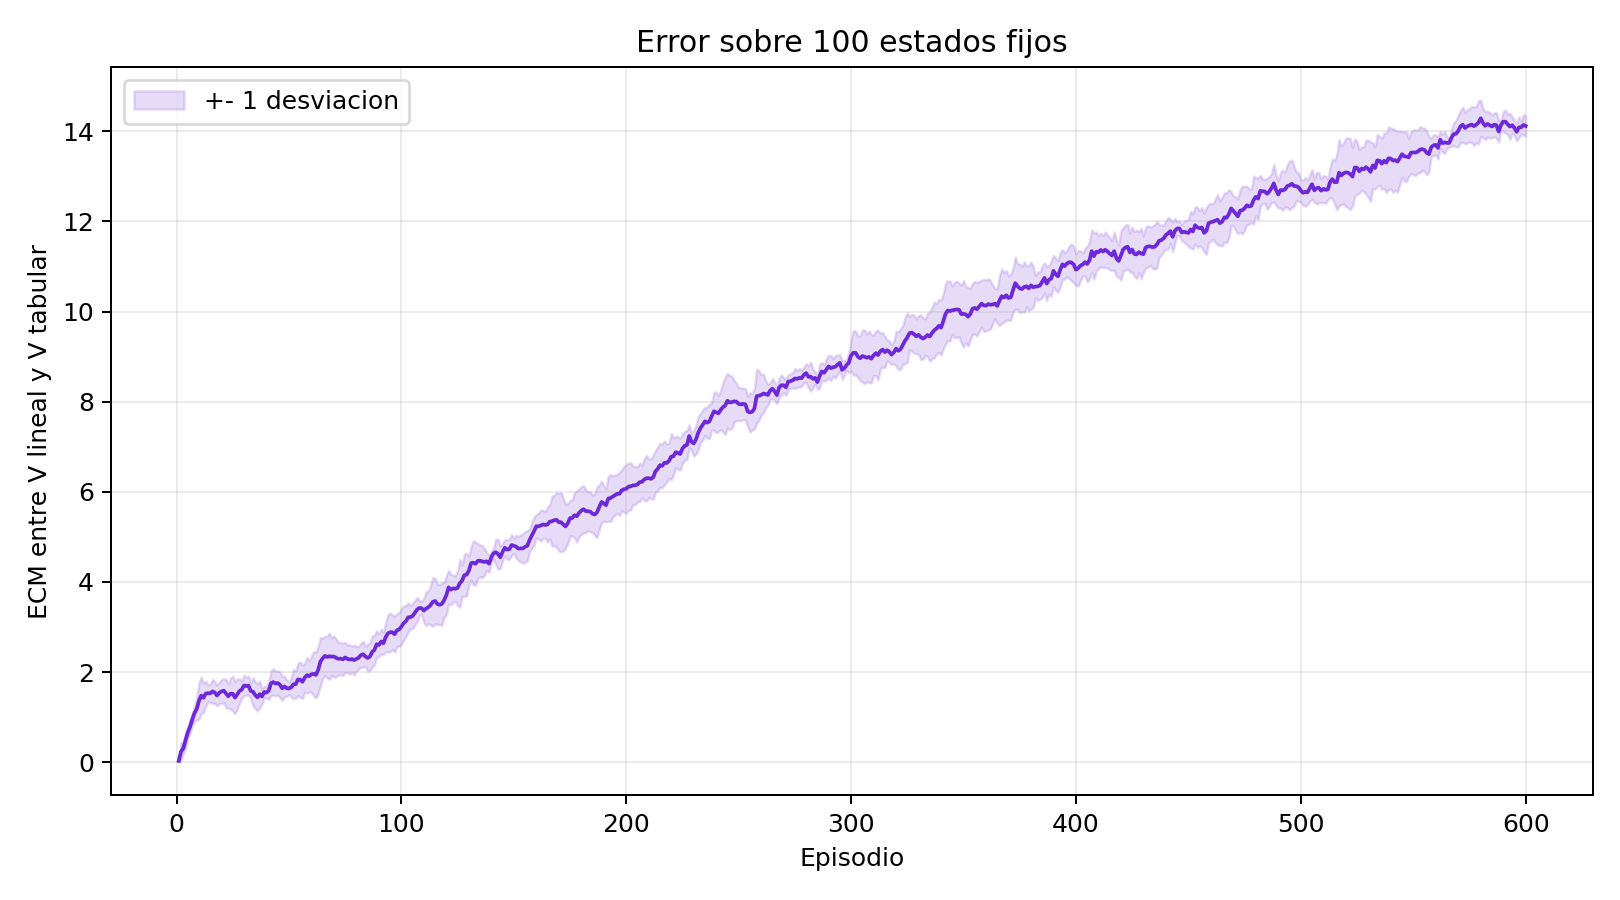

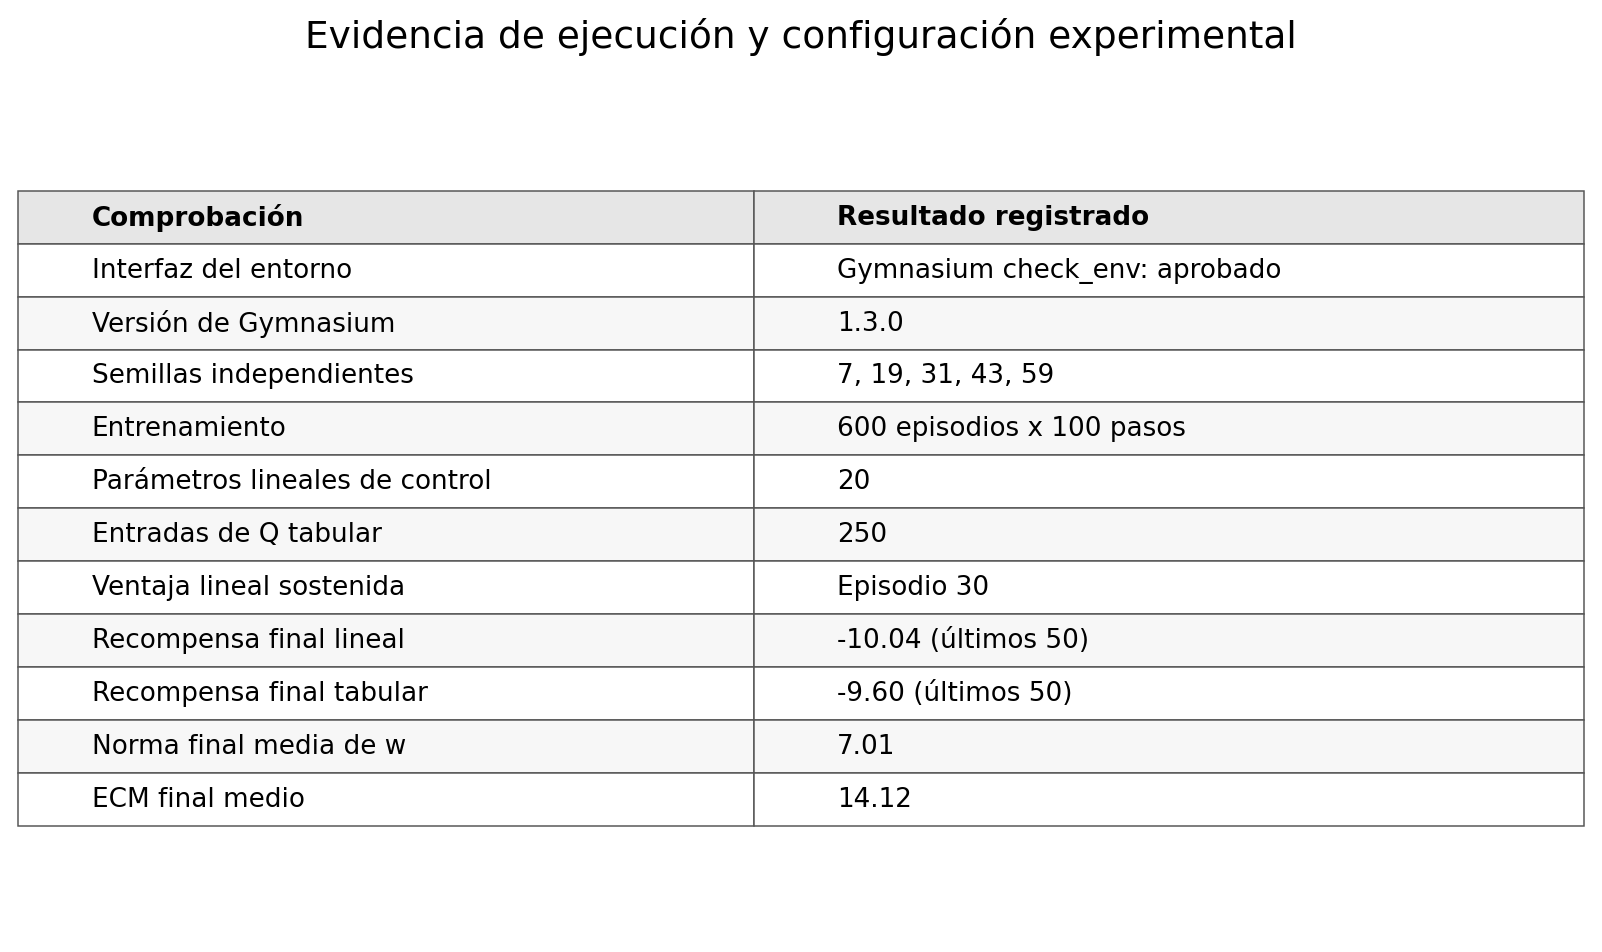

In [3]:
from IPython.display import Image, display
for filename in [
    "resultados/fig1_curvas_aprendizaje.png",
    "resultados/fig2_norma_pesos.png",
    "resultados/fig3_error_cuadratico.png",
    "resultados/fig4_evidencia_ejecucion.png",
]:
    display(Image(filename=filename))

## Lectura de resultados

- La ventaja temprana sostenida del aproximador lineal empieza alrededor del episodio **30**, usando media móvil de 30 episodios y exigiendo 20 puntos consecutivos. La generalización permite actualizar muchos estados parecidos desde cada transición.
- En los últimos 50 episodios, Q-Learning termina ligeramente arriba: **-9.60** frente a **-10.04** para el método lineal (mayor recompensa es mejor). Por tanto, el resultado no permite declarar un ganador universal.
- La norma final media es **7.01** y su pendiente media en los últimos 50 episodios es **0.0048** por episodio. No hay explosión, pero tampoco convergencia plana dentro de 600 episodios; conviene probar un α menor o decreciente y revisar las características.
- El ECM final medio es **14.12**. Este valor mide desacuerdo entre dos estimadores aprendidos, no distancia respecto de un valor óptimo conocido.

La interpretación completa, el análisis teórico, el paper y el dictamen están en el PDF.